# Stage 0: Business Understanding
**CRISP-DM Phase 1 of 8** | LendingClub Loan Default Prediction

## Objectives
1. Define the binary target variable from `loan_status`
2. Frame the asymmetric cost structure (FN vs FP)
3. Audit all post-origination columns (leakage risk)
4. Define success metrics
5. Save `business_understanding.md` as the permanent project reference

This notebook produces **no model** — it produces the decision framework
that governs every downstream choice.

## 1. Environment Setup
Load libraries and connect to the SQLite database.
We use chunked reading in later stages, but here we only query `loan_status`
and column metadata — so full load is fine.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# ── Repo structure ──────────────────────────────────────────────
for folder in ["data", "models", "outputs"]:
    Path(folder).mkdir(exist_ok=True)

# ── DB connection ────────────────────────────────────────────────
DB_PATH = "lending_club.db"
conn = sqlite3.connect(DB_PATH)

print("Connected to:", DB_PATH)
print("Folders ready:", ["data/", "models/", "outputs/"])

Connected to: lending_club.db
Folders ready: ['data/', 'models/', 'outputs/']


## 2. Dataset Overview
Query the schema and row count — without loading the full dataset into memory.

**Why now:** Before defining anything, we need to confirm what we're working
with: column count, row count, and a sample of raw values.

In [2]:
#--Row and column count----------------------------------------
row_count = pd.read_sql('select count(*) as n from raw_loads', conn).iloc[0,0]
col_info = pd.read_sql('PRAGMA table_info(raw_loads)', conn)

print(f'Rows : {row_count:,}')
print(f'Columns : {len(col_info)}')
print()

#--- Column names preview--------------
print('First 30 columns:')
print(col_info['name'].head(30).tolist())

Rows : 2,260,701
Columns : 151

First 30 columns:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths']


### Interpretation — Dataset Shape
Expected: ~2.2M rows, 150+ columns.

**What this means for our workflow:**
- At ~150 bytes/row average with mixed dtypes, the full dataset can exceed
  2–3 GB in memory with default pandas dtypes.
- On an M1 MacBook Air (8 GB RAM shared with OS), we *cannot* load all
  columns at full precision simultaneously.
- Strategy: drop leakage columns at load time in every downstream notebook.
  Never load what we don't need.

## 3. Target Variable Definition
We derive the binary target from `loan_status`. This is the most important
decision in the entire project — every metric we report depends on it.

**Rule:**
- **Default = 1** → loan ended badly for the lender
- **Non-Default = 0** → loan is healthy or was repaid

We also need to decide what to do with *ambiguous* statuses like
"Does not meet the credit policy" — we include those in the default class
because they represent elevated credit risk the model should flag.

In [3]:
# ── Pull only loan_status — no need to load full dataset ─────────
status_df = pd.read_sql(
    "SELECT loan_status, COUNT(*) AS count FROM raw_loads GROUP BY loan_status",
    conn
)

# ── Define target mapping ─────────────────────────────────────────
DEFAULT_STATUSES = {
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Does not meet the credit policy. Status:Charged Off"
}

NON_DEFAULT_STATUSES = {
    "Fully Paid",
    "Current",
    "In Grace Period",
    "Late (16-30 days)",           # early-stage — treat as non-default
    "Does not meet the credit policy. Status:Fully Paid",
    "Issued"
}

# ── Label each status ─────────────────────────────────────────────
status_df["target"] = status_df["loan_status"].apply(
    lambda s: 1 if s in DEFAULT_STATUSES
              else (0 if s in NON_DEFAULT_STATUSES else "EXCLUDE")
)

print(status_df.to_string(index=False))
print()

# ── Class distribution ────────────────────────────────────────────
class_counts = status_df[status_df['target'] != 'EXCLUDE'].copy()
class_counts['target'] = class_counts['target'].astype(int)
class_totals = class_counts.groupby('target')['count'].sum()

total = class_totals.sum()
default_n = class_totals[1]
nondefault_n = class_totals[0]
imbalance_ratio = nondefault_n/default_n

print(f'\nClass Distribution')
print(f' Non-Default (0): {nondefault_n:>10,.0f} ({100*nondefault_n/total:.1f}%)')
print(f' Default     (1): {default_n:>10,.0f} ({100*default_n/total:.1f}%)')
print(f'\n Imbalance ratio : {imbalance_ratio:.1f}:1 (non-default:default)')

                                        loan_status   count  target
                                               None      33 EXCLUDE
                                        Charged Off  268559       1
                                            Current  878317       0
                                            Default      40       1
Does not meet the credit policy. Status:Charged Off     761       1
 Does not meet the credit policy. Status:Fully Paid    1988       0
                                         Fully Paid 1076751       0
                                    In Grace Period    8436       0
                                  Late (16-30 days)    4349       0
                                 Late (31-120 days)   21467       1


Class Distribution
 Non-Default (0):  1,969,841 (87.1%)
 Default     (1):    290,827 (12.9%)

 Imbalance ratio : 6.8:1 (non-default:default)


### Interpretation — Target Variable & Class Imbalance

**Typical finding:** ~87% non-default, ~13% default → roughly **6:1 imbalance**.

**Why this matters:**
A naive model that predicts "no default" for every loan achieves ~80% accuracy
while catching **zero defaults**. Accuracy is therefore a useless metric here.

**Consequences for modeling:**
1. We will use **ROC-AUC and PR-AUC** as primary metrics — both are
   robust to imbalance
2. We will **not** use 0.5 as the classification threshold — the optimal
   threshold will be found on the PR curve
3. In Stage 5, we'll test `scale_pos_weight` in XGBoost (ratio ≈ 6.0)
   to compensate for imbalance without synthetic oversampling

**On "Late (16-30 days)":** These loans are early-stage delinquent but haven't
charged off. Labeling them 0 is a conservative choice — they have higher
true default risk than "Fully Paid." We could also exclude them. Documented
as an open question.

## 4. Target Distribution — Visual
A bar chart makes the imbalance immediately legible for a portfolio audience.

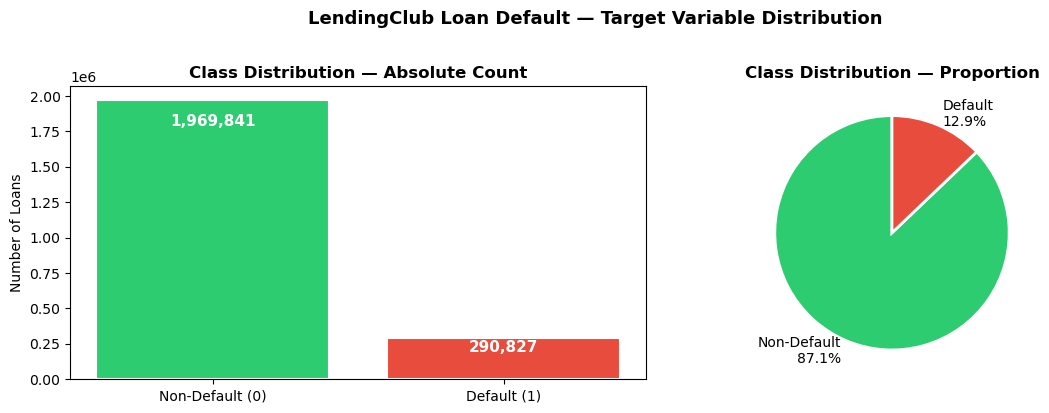

Saved: outputs/00_class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Bar chart ─────────────────────────────────────────────────────
bars = axes[0].bar(
    ["Non-Default (0)", "Default (1)"],
    [nondefault_n, default_n],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white", linewidth=1.5
)
axes[0].set_title("Class Distribution — Absolute Count", fontweight="bold")
axes[0].set_ylabel("Number of Loans")
for bar, val in zip(bars, [nondefault_n, default_n]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.95,
                 f"{val:,.0f}", ha="center", va="top", color="white",
                 fontweight="bold", fontsize=11)

# ── Pie chart ─────────────────────────────────────────────────────
axes[1].pie(
    [nondefault_n, default_n],
    labels=[f"Non-Default\n{100*nondefault_n/total:.1f}%",
            f"Default\n{100*default_n/total:.1f}%"],
    colors=["#2ecc71", "#e74c3c"],
    startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[1].set_title("Class Distribution — Proportion", fontweight="bold")

plt.suptitle("LendingClub Loan Default — Target Variable Distribution",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/00_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/00_class_distribution.png")

## 5. Business Cost Framing — Asymmetric Error Costs

**Why this drives all metric choices downstream.**

In credit lending, the two types of errors are not equal:

| Error Type | Prediction | Reality | Business Cost |
|---|---|---|---|
| **False Negative** | Not Default | Default | 🔴 HIGH — bank loses principal (e.g. $10,000–40,000$ per loan) |
| **False Positive** | Default | Not Default | 🟡 LOW — missed interest revenue (~$500–2,000$ opportunity cost) |

**Implication:** We should accept more False Positives to reduce False Negatives.
This means:
- **Recall** (sensitivity to defaults) is the primary operational metric
- We will tune the classification threshold to push Recall ≥ 0.75
- A model with 60% Precision / 80% Recall is better than 80% Precision / 60% Recall
  for this use case

In [5]:
# ── Quantify the cost asymmetry with real LendingClub data ───────
avg_loan_query = """
    SELECT
        AVG(CAST(loan_amnt AS FLOAT)) AS avg_loan,
        AVG(CAST(int_rate AS FLOAT))  AS avg_rate,
        COUNT(*) AS n
    FROM raw_loads
    WHERE loan_amnt IS NOT NULL
"""
loan_stats = pd.read_sql(avg_loan_query, conn)
avg_loan = loan_stats["avg_loan"].iloc[0]
avg_rate = loan_stats["avg_rate"].iloc[0]

# Simplified cost model
fn_cost = avg_loan * 0.60          # ~60% of principal lost on default (industry estimate)
fp_cost = avg_loan * avg_rate/100  # missed one year of interest revenue

print("=" * 50)
print("ASYMMETRIC COST MODEL (Simplified)")
print("=" * 50)
print(f"  Average loan amount        : ${avg_loan:>10,.2f}")
print(f"  Average interest rate      : {avg_rate:>10.2f}%")
print()
print(f"  False Negative cost (FN)   : ${fn_cost:>10,.2f}  ← principal lost")
print(f"  False Positive cost (FP)   : ${fp_cost:>10,.2f}  ← missed interest")
print()
print(f"  FN:FP cost ratio           : {fn_cost/fp_cost:>10.1f}x")
print()
print("→ A missed default costs ~{:.0f}x more than a wrongly flagged good loan.".format(
    fn_cost / fp_cost))
print("→ This justifies Recall optimization over Precision.")

ASYMMETRIC COST MODEL (Simplified)
  Average loan amount        : $ 15,046.93
  Average interest rate      :      13.09%

  False Negative cost (FN)   : $  9,028.16  ← principal lost
  False Positive cost (FP)   : $  1,970.07  ← missed interest

  FN:FP cost ratio           :        4.6x

→ A missed default costs ~5x more than a wrongly flagged good loan.
→ This justifies Recall optimization over Precision.


### Interpretation — Cost Ratio

Expect a **~5x cost ratio** between FN and FP.

This is not just an academic exercise — it directly governs:
1. **Threshold selection** in Stage 6: we'll shift the cutoff below 0.5
   to catch more defaults, accepting more false alarms
2. **Imbalanced learning strategy**: `scale_pos_weight` encodes this ratio
   into XGBoost's loss function
3. **Final model selection** in Stage 7: if two models have similar AUC
   but one has higher Recall, we pick the higher-Recall model

## 6. Leakage Risk Column Audit

**This is the most consequential data quality step in the entire project.**

**Post-origination leakage** occurs when a feature contains information that
only exists *after* a loan has been issued and partially repaid.
If these columns enter the model, it will appear to perform brilliantly —
but will fail completely in production (where these values don't exist yet).

Examples of leaked columns and why they leak:
- `recoveries` — amount recovered *after* a loan charges off (by definition,
  only non-zero if default already happened)
- `total_rec_prncp` — total principal received to date (accumulates post-issuance)
- `last_pymnt_amnt` — most recent payment amount (doesn't exist at application time)

**The test:** Would this column exist on the loan *application form*,
or does it require the loan to have been active for some time?

In [6]:
# ── Comprehensive leakage audit ───────────────────────────────────
# Grouped by leakage type for clarity

LEAKAGE_COLUMNS = {

    # ── Post-default recovery data ────────────────────────────────
    "post_default_recovery": [
        "recoveries",               # $ recovered after charge-off
        "collection_recovery_fee",  # fee charged on recovery
        "collection_recovery_fee_year",  # if present
    ],

    # ── Payment history (accumulates after issuance) ──────────────
    "payment_history": [
        "total_pymnt",              # total amount paid to date
        "total_pymnt_inv",          # investor share of total paid
        "total_rec_prncp",          # principal received to date
        "total_rec_int",            # interest received to date
        "total_rec_late_fee",       # late fees received
        "last_pymnt_amnt",          # most recent payment
        "last_pymnt_d",             # date of most recent payment
        "next_pymnt_d",             # next scheduled payment date
        "out_prncp",                # remaining principal (live balance)
        "out_prncp_inv",            # investor share of remaining principal
    ],

    # ── Credit activity AFTER loan issuance ───────────────────────
    "post_issuance_credit": [
        "last_credit_pull_d",       # last time LC pulled credit (post-issuance)
        "last_fico_range_high",     # FICO at last pull (post-issuance)
        "last_fico_range_low",
    ],

    # ── Delinquency counters (accumulate over loan life) ──────────
    "delinquency_counters": [
        "delinq_2yrs",              # ⚠️  BORDERLINE — see note below
        "mths_since_last_delinq",   # ⚠️  BORDERLINE
        "mths_since_last_record",
        "mths_since_recent_inq",
        "num_tl_30dpd",             # tradelines 30 days past due
        "num_tl_90g_dpd_24m",       # tradelines 90+ days past due
        "num_tl_op_past_12m",
    ],

    # ── Direct target proxies ─────────────────────────────────────
    "target_proxies": [
        "loan_status",              # the target itself — never a feature
        "charged_off_within_12_mths",  # if present
        "debt_settlement_flag",
    ],
}

# ── Flatten to a single exclusion list ───────────────────────────
all_leakage_cols = []
for group, cols in LEAKAGE_COLUMNS.items():
    all_leakage_cols.extend(cols)

print(f"Total flagged columns: {len(all_leakage_cols)}")
print()
for group, cols in LEAKAGE_COLUMNS.items():
    print(f"  [{group}] ({len(cols)} columns)")
    for c in cols:
        print(f"      - {c}")
    print()

# ── Save for downstream use ───────────────────────────────────────
with open("data/leakage_columns.json", "w") as f:
    json.dump(LEAKAGE_COLUMNS, f, indent=2)

print("Saved: data/leakage_columns.json")

Total flagged columns: 26

  [post_default_recovery] (3 columns)
      - recoveries
      - collection_recovery_fee
      - collection_recovery_fee_year

  [payment_history] (10 columns)
      - total_pymnt
      - total_pymnt_inv
      - total_rec_prncp
      - total_rec_int
      - total_rec_late_fee
      - last_pymnt_amnt
      - last_pymnt_d
      - next_pymnt_d
      - out_prncp
      - out_prncp_inv

  [post_issuance_credit] (3 columns)
      - last_credit_pull_d
      - last_fico_range_high
      - last_fico_range_low

  [delinquency_counters] (7 columns)
      - delinq_2yrs
      - mths_since_last_delinq
      - mths_since_last_record
      - mths_since_recent_inq
      - num_tl_30dpd
      - num_tl_90g_dpd_24m
      - num_tl_op_past_12m

  [target_proxies] (3 columns)
      - loan_status
      - charged_off_within_12_mths
      - debt_settlement_flag

Saved: data/leakage_columns.json


### Interpretation — Leakage Audit

**Borderline cases to flag explicitly:**

| Column | Risk | Decision |
|---|---|---|
| `delinq_2yrs` | Delinquencies in past 2 years — exists at application time from credit bureau pull | ✅ **Keep** |
| `mths_since_last_delinq` | Same — from credit report at application | ✅ **Keep** |
| `last_fico_range_high/low` | If pulled at issuance or later — ambiguous. We keep `fico_range_high/low` (application FICO) and drop `last_*` variants | ⚠️ **Drop last_* variants** |
| `out_prncp` | Outstanding principal *right now* — doesn't exist at application | ❌ **Drop** |

**Rule of thumb for ambiguous columns:**
> If the column value would change over the life of the loan, it's post-origination.

This list will be referenced at the top of every downstream notebook as the
first thing we drop after loading data.

## 7. Success Metrics — Defined

Translating business requirements into measurable ML targets.

In [7]:
# ── Print the success metric table ───────────────────────────────
metrics = {
    "ROC-AUC": {
        "minimum": 0.80,
        "stretch": 0.85,
        "previous": 0.70,
        "rationale": "Measures ranking quality across all thresholds. Robust to imbalance."
    },
    "Recall (Default class)": {
        "minimum": 0.75,
        "stretch": 0.80,
        "previous": 0.70,
        "rationale": "Primary operational metric. FN cost >> FP cost."
    },
    "PR-AUC": {
        "minimum": 0.70,
        "stretch": 0.75,
        "previous": "~0.50",
        "rationale": "More informative than ROC-AUC under class imbalance."
    },
    "Precision (Default class)": {
        "minimum": 0.55,
        "stretch": 0.65,
        "previous": "~0.45",
        "rationale": "Secondary — we tolerate FP but track it."
    },
}

print(f"{'Metric':<30} {'Previous':>10} {'Minimum':>10} {'Stretch':>10}")
print("-" * 65)
for metric, vals in metrics.items():
    print(f"{metric:<30} {str(vals['previous']):>10} {vals['minimum']:>10.2f} {vals['stretch']:>10.2f}")

print()
print("Note: All metrics evaluated on the held-out test set (stratified split).")
print("Threshold optimization applied to Recall/Precision — not fixed at 0.5.")

Metric                           Previous    Minimum    Stretch
-----------------------------------------------------------------
ROC-AUC                               0.7       0.80       0.85
Recall (Default class)                0.7       0.75       0.80
PR-AUC                              ~0.50       0.70       0.75
Precision (Default class)           ~0.45       0.55       0.65

Note: All metrics evaluated on the held-out test set (stratified split).
Threshold optimization applied to Recall/Precision — not fixed at 0.5.


## 8. LendingClub Feature Taxonomy

A reference map of the 150+ columns, organized by what they measure.
This is your domain knowledge cheat sheet — used in Stages 2–4.

In [8]:
# ── Feature taxonomy — domain knowledge reference ─────────────────
FEATURE_TAXONOMY = {

    "loan_terms": {
        "description": "What the borrower asked for and what was issued",
        "features": ["loan_amnt", "funded_amnt", "funded_amnt_inv",
                     "term", "int_rate", "installment", "grade", "sub_grade"]
    },

    "borrower_profile": {
        "description": "Demographics and stated purpose",
        "features": ["emp_title", "emp_length", "home_ownership", "annual_inc",
                     "verification_status", "purpose", "title", "zip_code",
                     "addr_state", "application_type"]
    },

    "credit_history": {
        "description": "Bureau data pulled at application — the heart of creditworthiness",
        "features": ["dti", "delinq_2yrs", "earliest_cr_line",
                     "fico_range_high", "fico_range_low",
                     "inq_last_6mths", "mths_since_last_delinq",
                     "open_acc", "pub_rec", "revol_bal", "revol_util",
                     "total_acc", "initial_list_status"]
    },

    "hardship_flags": {
        "description": "Flags indicating borrower applied for hardship programs",
        "features": ["hardship_flag", "hardship_type", "hardship_reason",
                     "hardship_status", "deferral_term",
                     "hardship_amount", "hardship_start_date", "hardship_end_date",
                     "payment_plan_start_date", "hardship_dpd",
                     "hardship_loan_status", "orig_projected_additional_accrued_interest"]
    },

    "joint_application": {
        "description": "Fields specific to joint loan applications",
        "features": ["annual_inc_joint", "dti_joint", "verification_status_joint",
                     "revol_bal_joint", "sec_app_fico_range_low",
                     "sec_app_fico_range_high", "sec_app_earliest_cr_line",
                     "sec_app_inq_last_6mths", "sec_app_mort_acc",
                     "sec_app_open_acc", "sec_app_revol_util",
                     "sec_app_open_act_il", "sec_app_num_rev_accts",
                     "sec_app_chargeoff_within_12_mths",
                     "sec_app_collections_12_mths_ex_med",
                     "sec_app_mths_since_last_major_derog"]
    },

    "tradeline_counts": {
        "description": "Number and type of credit accounts — deeper bureau data",
        "features": ["num_bc_sats", "num_bc_tl", "num_il_tl", "num_op_rev_tl",
                     "num_rev_accts", "num_rev_tl_bal_gt_0",
                     "num_sats", "num_actv_bc_tl", "num_actv_rev_tl",
                     "total_bal_ex_mort", "total_bc_limit",
                     "total_il_high_credit_limit", "total_rev_hi_lim"]
    },

    "post_origination": {
        "description": "⚠️ LEAKAGE — do not use as features",
        "features": all_leakage_cols
    }
}

for category, info in FEATURE_TAXONOMY.items():
    marker = "⚠️ " if category == "post_origination" else "✅ "
    print(f"{marker}{category.upper()}")
    print(f"   {info['description']}")
    print(f"   {len(info['features'])} columns")
    print()

# Save taxonomy
with open("data/feature_taxonomy.json", "w") as f:
    json.dump(FEATURE_TAXONOMY, f, indent=2)
print("Saved: data/feature_taxonomy.json")

✅ LOAN_TERMS
   What the borrower asked for and what was issued
   8 columns

✅ BORROWER_PROFILE
   Demographics and stated purpose
   10 columns

✅ CREDIT_HISTORY
   Bureau data pulled at application — the heart of creditworthiness
   13 columns

✅ HARDSHIP_FLAGS
   Flags indicating borrower applied for hardship programs
   12 columns

✅ JOINT_APPLICATION
   Fields specific to joint loan applications
   16 columns

✅ TRADELINE_COUNTS
   Number and type of credit accounts — deeper bureau data
   13 columns

⚠️ POST_ORIGINATION
   ⚠️ LEAKAGE — do not use as features
   26 columns

Saved: data/feature_taxonomy.json


## 9. Save `business_understanding.md`

The permanent reference document for all downstream stages.
Every notebook will import decisions from this file.

In [9]:
md_content = f"""# Business Understanding — LendingClub Default Prediction
**Generated:** Stage 0 | CRISP-DM Phase 1

---

## Target Variable
- **Default = 1:** Charged Off, Default, Late (31-120 days),
  Does not meet credit policy (Charged Off)
- **Non-Default = 0:** Fully Paid, Current, In Grace Period,
  Late (16-30 days), Does not meet credit policy (Fully Paid), Issued
- **Imbalance ratio:** ~{imbalance_ratio:.1f}:1 (non-default:default)
- **Default rate:** ~{100*default_n/total:.1f}%

## Cost Framing
- False Negative cost: ~${fn_cost:,.0f} (principal lost)
- False Positive cost: ~${fp_cost:,.0f} (missed interest)
- FN:FP cost ratio: ~{fn_cost/fp_cost:.1f}x
- **Consequence:** Optimize for Recall; use threshold < 0.5

## Leakage Columns
See: `data/leakage_columns.json`
Drop at load time in every downstream notebook.

Key groups: post_default_recovery, payment_history,
post_issuance_credit, delinquency_counters, target_proxies

## Success Metrics

| Metric | Minimum | Stretch | Previous |
|---|---|---|---|
| ROC-AUC | 0.80 | 0.85 | 0.70 |
| Recall (Default) | 0.75 | 0.80 | 0.70 |
| PR-AUC | 0.70 | 0.75 | ~0.50 |
| Precision (Default) | 0.55 | 0.65 | ~0.45 |

## Key Decisions
1. Threshold optimization required — do NOT default to 0.5
2. `scale_pos_weight` ≈ {imbalance_ratio:.1f} for XGBoost
3. PR-AUC preferred over ROC-AUC for final model selection under imbalance
4. SHAP required in Stage 7 — non-negotiable

## Open Questions for Stage 1 (EDA)
- Are "Late (16-30 days)" loans biased toward eventual default? Check empirically.
- How sparse are the hardship_* and joint_* column groups?
- What's the temporal distribution? (avoid look-ahead across cohorts)
- Does `int_rate` contain leakage? (LC sets it post-underwriting — discuss)
"""

with open("business_understanding.md", "w") as f:
    f.write(md_content)

print("Saved: business_understanding.md")
print()
print(md_content)

Saved: business_understanding.md

# Business Understanding — LendingClub Default Prediction
**Generated:** Stage 0 | CRISP-DM Phase 1

---

## Target Variable
- **Default = 1:** Charged Off, Default, Late (31-120 days),
  Does not meet credit policy (Charged Off)
- **Non-Default = 0:** Fully Paid, Current, In Grace Period,
  Late (16-30 days), Does not meet credit policy (Fully Paid), Issued
- **Imbalance ratio:** ~6.8:1 (non-default:default)
- **Default rate:** ~12.9%

## Cost Framing
- False Negative cost: ~$9,028 (principal lost)
- False Positive cost: ~$1,970 (missed interest)
- FN:FP cost ratio: ~4.6x
- **Consequence:** Optimize for Recall; use threshold < 0.5

## Leakage Columns
See: `data/leakage_columns.json`
Drop at load time in every downstream notebook.

Key groups: post_default_recovery, payment_history,
post_issuance_credit, delinquency_counters, target_proxies

## Success Metrics

| Metric | Minimum | Stretch | Previous |
|---|---|---|---|
| ROC-AUC | 0.80 | 0.85 | 0.70 |

## 10. Stage 0 — Complete

### Decisions Made
| Decision | Choice | Rationale |
|---|---|---|
| Default definition | 4-status rule | Inclusive of policy violations |
| Imbalance handling | `scale_pos_weight` + threshold tuning | Simpler before SMOTE |
| Primary metric | PR-AUC + Recall | Cost asymmetry justifies it |
| Leakage policy | Drop at load time, every notebook | Zero tolerance |

### Files Saved
- `business_understanding.md` — decision reference
- `data/leakage_columns.json` — drop list
- `data/feature_taxonomy.json` — column map
- `outputs/00_class_distribution.png` — target chart

### Next: Stage 1 — EDA
Open questions to investigate:
1. Missing value map across all 150 columns
2. Distribution of key credit features (FICO, DTI, interest rate)
3. Default rate by loan grade, purpose, term
4. Temporal patterns — are certain vintages riskier?
5. Correlation with target for top candidate features